# 01 — EDA: знакомство с данными

Цель этого ноутбука — посмотреть на сырые данные глазами антифрод-аналитика и **подсветить аномалии**, на которых дальше будем строить признаки.

Пять секций под пять признаков из разбора кейса:
1. Профили: возраст аккаунта, заполненность, аватар.
2. Тайминги: распределение действий по времени, синхронные всплески подписок на пирамиды.
3. Регулярность: интервалы между действиями (и почему наивный CV нас обманывает).
4. Тексты: как одинаковые комментарии расходятся по сети.
5. Связи: подписки, кольца внутри ферм.

В конце — список фич, которые перенесём в `src/features.py`.

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.3f}'.format


In [2]:
users = pd.read_csv('../data/raw/users.csv', parse_dates=['registration_date'])
actions = pd.read_csv('../data/raw/actions.csv', parse_dates=['ts'])
comments = pd.read_csv('../data/raw/comments.csv', parse_dates=['ts'])
follows = pd.read_csv('../data/raw/follows.csv', parse_dates=['ts'])
pyramids = pd.read_csv('../data/raw/pyramids.csv')

print('users   ', users.shape)
print('actions ', actions.shape)
print('comments', comments.shape)
print('follows ', follows.shape)
print('pyramids', pyramids.shape)
print('доля ботов в users:', users.is_bot.mean())


users    (2160, 6)
actions  (89505, 7)
comments (18654, 5)
follows  (33715, 3)
pyramids (10, 3)
доля ботов в users: 0.07407407407407407


## 1. Профили

В реальной задаче `is_bot` нам недоступен, но в синтетике — есть, и я использую его **только для визуализации** (чтобы было понятно, что мы вообще ловим). На обучении ниже ground truth не уйдёт.

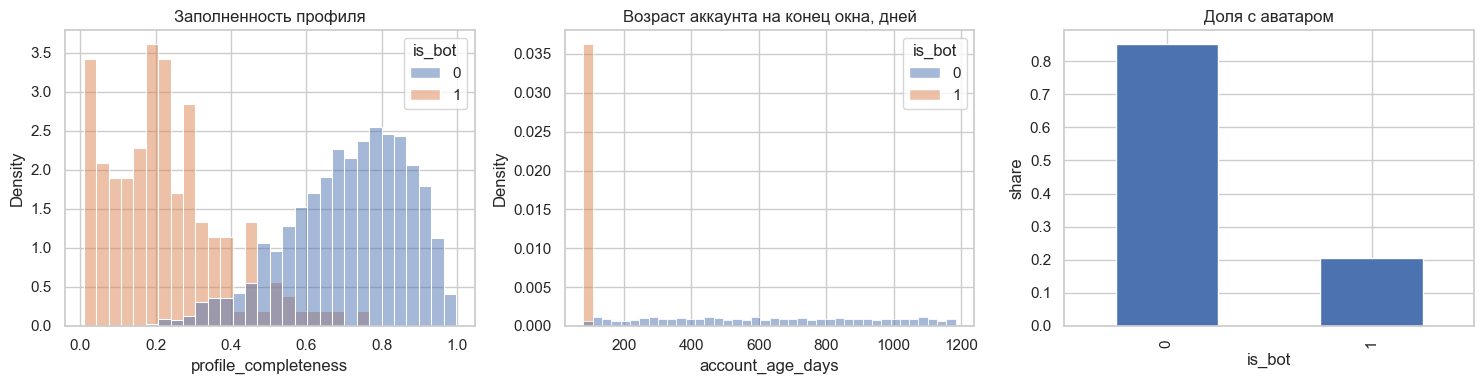

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=users, x='profile_completeness', hue='is_bot', bins=30, ax=axes[0], stat='density', common_norm=False)
axes[0].set_title('Заполненность профиля')
users['account_age_days'] = (pd.Timestamp('2026-03-31') - users.registration_date).dt.days
sns.histplot(data=users, x='account_age_days', hue='is_bot', bins=40, ax=axes[1], stat='density', common_norm=False)
axes[1].set_title('Возраст аккаунта на конец окна, дней')
users.groupby('is_bot')['has_avatar'].mean().plot.bar(ax=axes[2])
axes[2].set_title('Доля с аватаром')
axes[2].set_ylabel('share')
plt.tight_layout(); plt.show()


**Что видно:** боты живут <100 дней, с пустыми профилями и без аватаров. Это не one-shot-сигнал (новички существуют), но в комбо с поведением — мощный фильтр.

## 2. Тайминги: всплески подписок на пирамиды

Атака фермы выглядит как вертикальный скачок на CDF подписок. На обычных сообществах подписки приходят равномерно (~линейный наклон во времени).

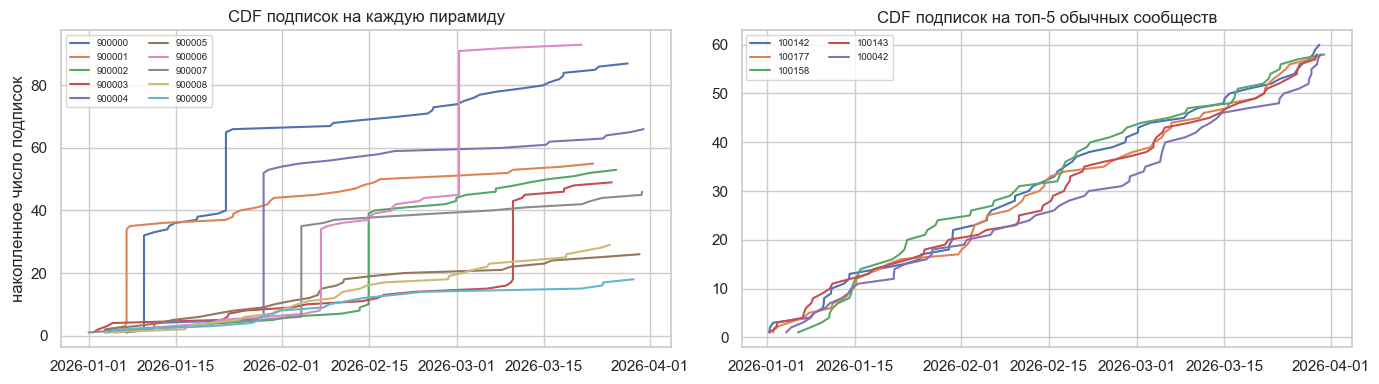

In [4]:
pyramid_ids = set(pyramids.target_id)
subs = actions[(actions.action_type=='subscribe')].copy()
subs['is_pyramid'] = subs.target_id.isin(pyramid_ids)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for pid, grp in subs[subs.is_pyramid].groupby('target_id'):
    grp_sorted = grp.sort_values('ts')
    axes[0].plot(grp_sorted.ts, np.arange(1, len(grp_sorted)+1), label=str(pid))
axes[0].set_title('CDF подписок на каждую пирамиду')
axes[0].set_ylabel('накопленное число подписок')
axes[0].legend(fontsize=7, ncol=2)

# сравнение с обычным сообществом (выберем самое популярное)
popular_normal = subs[~subs.is_pyramid].target_id.value_counts().head(5).index
for tid in popular_normal:
    grp_sorted = subs[subs.target_id == tid].sort_values('ts')
    axes[1].plot(grp_sorted.ts, np.arange(1, len(grp_sorted)+1), label=str(tid))
axes[1].set_title('CDF подписок на топ-5 обычных сообществ')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


На пирамидах видны **вертикальные ступени** — ферма пришла залпом за минуту-две. На обычных сообществах рост плавный.

In [5]:
# таблично: для каждой пирамиды найдём самое тесное окно из 10 подряд подписок
rows = []
for pid, grp in subs[subs.is_pyramid].groupby('target_id'):
    g = grp.sort_values('ts').reset_index(drop=True)
    if len(g) < 10: continue
    deltas = g.ts.iloc[9:].values - g.ts.iloc[:-9].values
    min_win_min = pd.to_timedelta(deltas.min()).total_seconds() / 60
    rows.append({'pyramid': pid, 'subscribers': len(g), 'min_window_10_min': round(min_win_min, 2)})
pd.DataFrame(rows).sort_values('min_window_10_min')


,pyramid,subscribers,min_window_10_min
6,900006,93,0.280
4,900004,66,0.470
1,900001,55,0.660
2,900002,53,0.720
7,900007,46,0.800
0,900000,87,1.090
3,900003,49,1.170
5,900005,26,18608.730
8,900008,29,22082.140
9,900009,18,33019.580


## 3. Интервалы между действиями: парадокс CV

Гипотеза из устного ответа: у ботов интервалы **слишком ровные**, значит CV (std/mean) низкий. Проверим, и сразу удивимся.

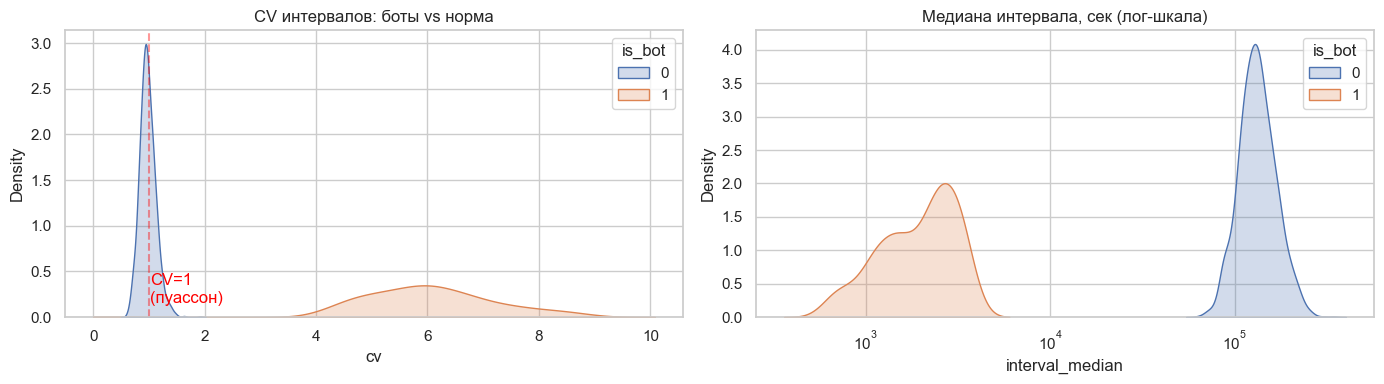

        interval_mean  interval_median    cv
is_bot                                      
0          187517.543       131153.050 0.963
1           59319.541         2159.741 5.958


In [6]:
actions_sorted = actions.sort_values(['user_id','ts'])
actions_sorted['interval'] = actions_sorted.groupby('user_id')['ts'].diff().dt.total_seconds()

user_cv = actions_sorted.dropna(subset=['interval']).groupby('user_id')['interval'].agg(
    interval_mean='mean', interval_std='std', interval_median='median', n='size'
).assign(cv=lambda d: d.interval_std / d.interval_mean.clip(lower=1))
user_cv = user_cv.join(users.set_index('user_id')[['is_bot']])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(data=user_cv, x='cv', hue='is_bot', fill=True, common_norm=False, clip=(0, 15), ax=axes[0])
axes[0].set_title('CV интервалов: боты vs норма')
axes[0].axvline(1, color='red', ls='--', alpha=0.4)
axes[0].text(1.02, 0.05, 'CV=1\n(пуассон)', color='red', transform=axes[0].get_xaxis_transform())

sns.kdeplot(data=user_cv, x='interval_median', hue='is_bot', fill=True, common_norm=False, log_scale=True, ax=axes[1])
axes[1].set_title('Медиана интервала, сек (лог-шкала)')
plt.tight_layout(); plt.show()

print(user_cv.groupby('is_bot')[['interval_mean','interval_median','cv']].median())


**Парадокс:** у ботов CV получился **выше** нормы (≈6 против ≈1). Почему?

Бот делает миксованную активность: фоновое расписание (раз в 10-60 минут, ровные интервалы) плюс **залп из 3 действий за 1 минуту** во время атаки на пирамиду. Небольшие интервалы залпа на фоне больших фоновых ломают равенство std≈mean.

Что брать в фичи вместо CV:
- `interval_median` — у ботов 2000 сек vs 130000 у нормы (видно на правом графике).
- `interval_p10` — нижний хвост распределения, ловит залпы.
- `min_window_5_sec` — минимальное окно из 5 действий подряд.

## 4. Тексты: одинаковые комменты у разных пользователей

Считаем точные совпадения. В `features.py` мы добавим MinHash-фуззи поиск, но даже точные дубли уже всё показывают.

In [7]:
comments_with_label = comments.merge(users[['user_id','is_bot']], on='user_id')
text_user_count = comments_with_label.groupby('text')['user_id'].nunique().sort_values(ascending=False)
print('Топ повторяющихся текстов (число РАЗНЫХ юзеров, написавших одно и то же):')
print(text_user_count.head(15).to_string())
print()
popular = text_user_count[text_user_count >= 5].index
shared_users = comments_with_label[comments_with_label.text.isin(popular)]
print('Доля is_bot среди авторов часто повторяющихся текстов:',
      shared_users.is_bot.mean())


Топ повторяющихся текстов (число РАЗНЫХ юзеров, написавших одно и то же):
text
Вот это тема! Зашел сюда, вывел 100000 на карту. Кто еще в деле?    96
Вот это тема! Зашел сюда, вывел 50000 на карту. Кто еще в деле?     95
Вот это тема! Зашел сюда, вывел 200000 на карту. Кто еще в деле?    91
Вот это тема! Зашел сюда, вывел 150000 на карту. Кто еще в деле?    86
Вот это тема! Зашел сюда, вывел 75000 на карту. Кто еще в деле?     85
Админы молодцы, проект топ, 150000 вывел, жду следующую выплату     52
Залетайте пока не поздно, я вывел 100000 без проблем                50
Админы молодцы, проект топ, 100000 вывел, жду следующую выплату     48
Залетайте пока не поздно, я вывел 50000 без проблем                 47
Залетайте пока не поздно, я вывел 75000 без проблем                 47
Админы молодцы, проект топ, 200000 вывел, жду следующую выплату     44
Залетайте пока не поздно, я вывел 150000 без проблем                44
Админы молодцы, проект топ, 75000 вывел, жду следующую выплату      4

## 5. Граф подписок: плотные сообщества

Считаем долю взаимных подписок. У реального юзера это редкое явление (подписка обычно асимметрична), у фермы — почти всегда.

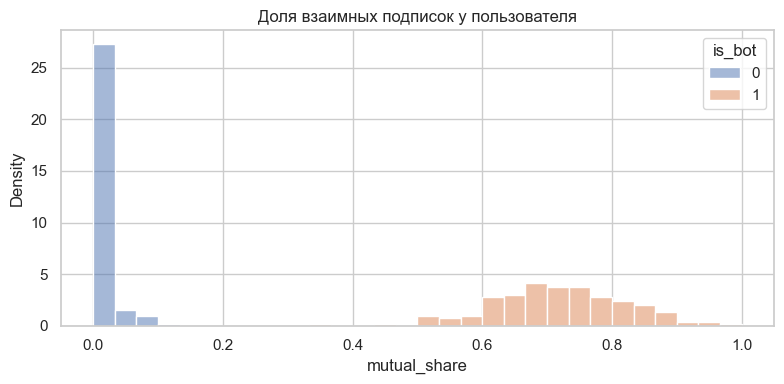

          count  mean   std   min   25%   50%   75%   max
is_bot                                                   
0      2000.000 0.006 0.022 0.000 0.000 0.000 0.000 0.333
1       160.000 0.718 0.103 0.364 0.647 0.714 0.789 1.000


In [8]:
edges = set(zip(follows.follower_id, follows.followed_id))
follows2 = follows.copy()
follows2['is_mutual'] = [(b,a) in edges for a,b in zip(follows2.follower_id, follows2.followed_id)]
mutual = follows2.groupby('follower_id')['is_mutual'].mean().rename('mutual_share')
mutual = mutual.to_frame().join(users.set_index('user_id')[['is_bot']])

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=mutual, x='mutual_share', hue='is_bot', stat='density', common_norm=False, bins=30, ax=ax)
ax.set_title('Доля взаимных подписок у пользователя')
plt.tight_layout(); plt.show()

print(mutual.groupby('is_bot')['mutual_share'].describe())


## Итог: что забираем в фичи

| Признак | Файл | Смысл |
|---|---|---|
| profile_completeness, has_avatar, account_age_days | profile | базовая статика |
| n_actions, n_subscribes, n_comments_action | activity | объём |
| pyramid_action_share | activity | связь с пирамидой |
| interval_median, interval_p10, min_window_5_sec | activity | бёрсты вместо наивного CV |
| n_unique_subnets, n_unique_uas, ip_entropy, ua_entropy | technical | концентрация устройств |
| duplicate_text_share, mean_text_neighbours | text | MinHash-сходство комментов |
| followers_count, following_count, mutual_follow_share | graph | кольцевые подписки |

Считаются в `src/features.py` — переходим в `02_features.ipynb`.